# LSTM Text Sentiment Classifier

Recurrent Neural Networks (RNN) and Long Short-Term Memory (LSTM) cells are designed to model sequential relationships, such as textual data. This project builds a complete NLP text preprocessing pipeline, maps word tokens into learned embedding vectors, and trains an LSTM model in PyTorch to classify review sentiments.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Synthetic dataset creation
corpus = [
    # Positive reviews
    ("great movie love it", 1),
    ("excellent book great story", 1),
    ("awesome performance love the cast", 1),
    ("perfect script excellent acting", 1),
    ("highly recommend great cinema", 1),
    ("amazing show love the directing", 1),
    ("beautiful acting good story", 1),
    ("fun comedy great entertainment", 1),
    
    # Negative reviews
    ("worst movie boring plot", 0),
    ("hate this book worst reading", 0),
    ("terrible acting bad script", 0),
    ("waste of time boring film", 0),
    ("horrible screenplay bad cast", 0),
    ("disappointed with this bad show", 0),
    ("dreadful acting worst plot", 0),
    ("unwatchable movie boring script", 0)
]

# Build vocabulary
vocab = {"<PAD>": 0}
for text, _ in corpus:
    for word in text.split():
        if word not in vocab:
            vocab[word] = len(vocab)

vocab_size = len(vocab)
print(f"Vocabulary Size: {vocab_size} words")
print("Vocabulary Mapping:", vocab)



Vocabulary Size: 44 words
Vocabulary Mapping: {'<PAD>': 0, 'great': 1, 'movie': 2, 'love': 3, 'it': 4, 'excellent': 5, 'book': 6, 'story': 7, 'awesome': 8, 'performance': 9, 'the': 10, 'cast': 11, 'perfect': 12, 'script': 13, 'acting': 14, 'highly': 15, 'recommend': 16, 'cinema': 17, 'amazing': 18, 'show': 19, 'directing': 20, 'beautiful': 21, 'good': 22, 'fun': 23, 'comedy': 24, 'entertainment': 25, 'worst': 26, 'boring': 27, 'plot': 28, 'hate': 29, 'this': 30, 'reading': 31, 'terrible': 32, 'bad': 33, 'waste': 34, 'of': 35, 'time': 36, 'film': 37, 'horrible': 38, 'screenplay': 39, 'disappointed': 40, 'with': 41, 'dreadful': 42, 'unwatchable': 43}


## Dataset Preprocessing & Padding

We convert sentences into sequences of vocabulary integer indexes. To form uniform tensor batches, we pad shorter sequences with `<PAD>` tokens (index 0) to match a fixed max sequence length of 5.



In [2]:
max_len = 5

def encode_text(text):
    tokens = text.split()
    # Truncate or pad
    seq = [vocab[w] for w in tokens[:max_len]]
    seq = seq + [0] * (max_len - len(seq))
    return seq

X_list = [encode_text(text) for text, _ in corpus]
y_list = [label for _, label in corpus]

X_tensor = torch.LongTensor(X_list)
y_tensor = torch.LongTensor(y_list)

print("First 3 Encoded and Padded Sentences:")
for i in range(3):
    print(f"Text: {corpus[i][0]} -> Encoded: {X_tensor[i].tolist()}")



First 3 Encoded and Padded Sentences:
Text: great movie love it -> Encoded: [1, 2, 3, 4, 0]
Text: excellent book great story -> Encoded: [5, 6, 1, 7, 0]
Text: awesome performance love the cast -> Encoded: [8, 9, 3, 10, 11]


## LSTM Model Architecture

We implement the sequence classifier in PyTorch:
1. **Embedding Layer**: Translates token integers into low-dimensional dense vectors.
2. **LSTM Layer**: Processes token vectors sequentially, capturing context.
3. **Linear Layer**: Classifies the final LSTM hidden state output into 2 sentiment categories (Negative = 0, Positive = 1).



In [3]:
class LSTMSentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(LSTMSentimentClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)  # shape: [batch_size, seq_len, embedding_dim]
        
        # lstm output shape: [batch_size, seq_len, hidden_dim]
        # h_n shape: [1, batch_size, hidden_dim] (last hidden state)
        out, (h_n, c_n) = self.lstm(embedded)
        
        # Extract the final sequence output step
        last_hidden = h_n.squeeze(0)  # shape: [batch_size, hidden_dim]
        return self.fc(last_hidden)

# Hyperparameters
embedding_dim = 8
hidden_dim = 16
output_dim = 2

model = LSTMSentimentClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.02)



## Model Training Loop

We train the LSTM classifier for 40 epochs. Because the dataset is small, the model quickly learns to differentiate polarity trigger keywords ("love", "worst", "great", "boring").



In [4]:
epochs = 40
losses = []
accuracies = []

for epoch in range(1, epochs + 1):
    model.train()
    
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate accuracy
    predictions = outputs.argmax(dim=1)
    correct = (predictions == y_tensor).sum().item()
    acc = correct / len(y_tensor)
    
    losses.append(loss.item())
    accuracies.append(acc)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}/{epochs} | Loss: {loss.item():.4f} | Accuracy: {acc*100:.1f}%")



Epoch 10/40 | Loss: 0.1750 | Accuracy: 100.0%
Epoch 20/40 | Loss: 0.0007 | Accuracy: 100.0%
Epoch 30/40 | Loss: 0.0001 | Accuracy: 100.0%
Epoch 40/40 | Loss: 0.0000 | Accuracy: 100.0%


## Sentiment Training Convergence

We plot the training loss curve and training classification accuracy over the epochs to demonstrate how the model learns to solve the text classification task.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



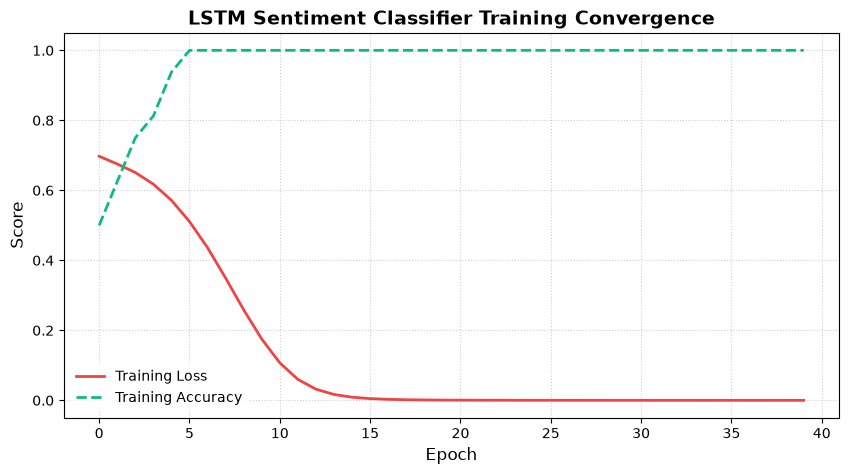

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss', color='#EF4444', linewidth=2)
plt.plot(accuracies, label='Training Accuracy', color='#10B981', linewidth=2, linestyle='--')
plt.title('LSTM Sentiment Classifier Training Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
